# 📉 Desarrollo del algoritmo
---

### 1. Introducción
El objetivo de este notebook es entrenar una **Inteligencia Artificial (Algoritmo Genético)** para predecir la crisis cambiaria de la Libra Esterlina en septiembre de 1992.

A diferencia de los modelos econométricos tradicionales, utilizamos un enfoque biológico basado la **Danger Theory** (Inmunología).
* **Hipótesis:** El mercado (organismo) emite "señales de peligro" internas (Intervención del Banco Central, Desempleo, Pérdida de Reservas) antes de que el precio (síntoma externo) colapse.
* **Método:** Evolucionamos una población de agentes digitales. Solo sobreviven aquellos que aprenden a leer estas señales ocultas para salir del mercado justo antes del colapso.

Importamos las librerias necesarias

In [ ]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from deap import base, creator, tools, algorithms

# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


### 2. Preparación del Entorno (ETL)

Esta es la fase más crítica. Integramos datos de fuentes heterogéneas con diferentes frecuencias:

1.  **Tipo de Cambio (Diario):** *Bank of England Database*.
2.  **Reservas (Mensual):** *IMF International Financial Statistics*.
3.  **Intervenciones (Diario):** *Datos de investigación del Dr. Alain Naef*. (La señal clave).
4.  **Desempleo (Mensual):** *Datos históricos UK*.

**Técnicas aplicadas:**
* **Forward Fill (`ffill`):** Para datos mensuales, asumimos que el dato se mantiene constante día a día hasta el siguiente reporte.
* **Normalización (Z-Score):** Transformamos todas las variables a una escala común (Desviaciones Estándar) para que el algoritmo pueda compararlas matemáticamente.

### 2.1. Ingeniería de Características: La Necesidad de la Normalización

Uno de los desafíos técnicos más importantes al integrar datos económicos es la **disparidad de escalas**. Nuestro modelo debe procesar simultáneamente variables con magnitudes radicalmente diferentes:

* **Reservas Internacionales:** Se miden en miles de millones (ej. `44,000,000,000`).
* **Tipo de Cambio (GBP/DEM):** Se mide en unidades pequeñas (ej. `2.95`).
* **Intervenciones:** Se miden en millones (ej. `200,000,000`).

Si introdujéramos estos datos "crudos" en el algoritmo, la variable de Reservas dominaría matemáticamente sobre las demás simplemente por ser un número más grande. El agente "ignoraría" el precio porque sus variaciones (0.01) son insignificantes comparadas con las variaciones de las reservas (1,000,000).

#### La Solución: Estandarización (Z-Score)

Para resolver esto, aplicamos una **Normalización Z-Score** a todas las variables de entrada (Genes). Transformamos cada valor $x$ en una puntuación $z$ usando la media ($\mu$) y la desviación estándar ($\sigma$) de su serie histórica:

$$z = \frac{x - \mu}{\sigma}$$

**¿Qué logramos con esto?**
1.  **Escala Común:** Todas las variables quedan centradas en **0** (el promedio) y se miden en **Desviaciones Estándar**.
2.  **Comparabilidad:** Un valor de `-2.0` en Reservas significa "extremadamente bajo" con la misma intensidad que un `-2.0` en el Precio.
3.  **Detección de Anomalías:** Los valores extremos (outliers), como la intervención masiva del Miércoles Negro, se destacan claramente (ej. `+15.0`), facilitando que el algoritmo los identifique como señales de peligro críticas.

In [8]:
def prepare_data_complete(file_rates, file_reserves, file_naef, file_unemp):
    print("🔄 Cargando y procesando datasets...")
    
    # --- 1. Cargar Tipos de Cambio (Diario) ---
    rates = pd.read_excel(file_rates, skiprows=3)
    rates = rates.iloc[3:].copy()
    rates.columns = ['Basura', 'Date', 'DEM', 'ITL', 'ESP', 'GBP']
    rates['Date'] = pd.to_datetime(rates['Date'])
    # Convertir a numérico asegurando que el punto es decimal
    rates['GBP'] = pd.to_numeric(rates['GBP'].astype(str).str.replace(',', '.'), errors='coerce')
    rates = rates[['Date', 'GBP']].dropna().sort_values('Date')

    # --- 2. Cargar Reservas (Mensual) ---
    reserves = pd.read_excel(file_reserves)
    reserves['Date'] = pd.to_datetime(reserves['Date'], dayfirst=True)
    reserves = reserves.sort_values('Date')

    # --- 3. Cargar Intervenciones Naef (Diario - Gen Crítico) ---
    # Usamos la hoja 'Main data clean' y decimal con coma (según tu Excel)
    naef = pd.read_excel(file_naef, sheet_name='Main data clean', decimal=',')
    naef = naef.iloc[:, [0, 1]] 
    naef.columns = ['Date', 'Intervention']
    naef['Date'] = pd.to_datetime(naef['Date'], dayfirst=True)
    naef['Intervention'] = pd.to_numeric(naef['Intervention'], errors='coerce').fillna(0)

    # --- 4. Cargar Desempleo (Mensual) ---
    unemp = pd.read_excel(file_unemp)
    # Ajuste específico para tu formato de archivo
    unemp = unemp.iloc[:, 0:2] 
    unemp.columns = ['DateStr', 'Unemployment']
    # Convertir formato "1990 JAN" a fecha real
    unemp['Date'] = pd.to_datetime(unemp['DateStr'], format='%Y %b', errors='coerce')
    unemp = unemp.dropna(subset=['Date']).sort_values('Date')

    # --- 5. FUSIÓN MAESTRA (MERGE) ---
    # Usamos las fechas diarias del precio como eje central
    df = pd.merge(rates, reserves, on='Date', how='left')
    df = pd.merge(df, naef, on='Date', how='left')
    df = pd.merge(df, unemp[['Date', 'Unemployment']], on='Date', how='left')
    
    df = df.sort_values('Date')
    
    # --- 6. RELLENO DE DATOS ---
    # Si hoy no hay dato mensual (Reservas/Paro), el agente ve el último publicado.
    df['Total Reserves'] = df['Total Reserves'].ffill()
    df['Unemployment'] = df['Unemployment'].ffill()
    # Si no hay dato de intervención diaria, asumimos 0.
    df['Intervention'] = df['Intervention'].fillna(0)
    
    # Filtramos para quedarnos con la ventana de la crisis
    mask = (df['Date'] >= '1990-01-01') & (df['Date'] <= '1993-01-01')
    df = df.loc[mask].reset_index(drop=True)
    df = df.dropna(subset=['Total Reserves', 'GBP', 'Unemployment'])

    # --- 7. INGENIERÍA DE GENES (NORMALIZACIÓN) ---
    # Transformamos todo a Z-Scores para que los pesos sean comparables
    
    # Gen 1: Reservas (Salud)
    df['Gen_Reservas'] = (df['Total Reserves'] - df['Total Reserves'].mean()) / df['Total Reserves'].std()
    
    # Gen 2: Precio (Señal engañosa)
    df['Gen_Precio'] = (df['GBP'] - df['GBP'].mean()) / df['GBP'].std()
    
    # Gen 3: Volatilidad (Miedo)
    vol = df['GBP'].rolling(30).std().fillna(0)
    df['Gen_Volatilidad'] = (vol - vol.mean()) / vol.std()
    
    # Gen 4: Intervención (Pánico del Banco Central)
    # Usamos valor absoluto (Magnitud del gasto)
    abs_int = df['Intervention'].abs()
    df['Gen_Intervencion'] = (abs_int - abs_int.mean()) / (abs_int.std() + 1e-6)
    
    # Gen 5: Desempleo (Debilidad Estructural)
    df['Gen_Desempleo'] = (df['Unemployment'] - df['Unemployment'].mean()) / df['Unemployment'].std()

    return df

# --- DEFINICIÓN DE RUTAS (Ajusta si es necesario) ---
path_rates = 'data/tipoDeCambioEuropa.xlsx'
path_reserves = 'data/ReservesData.xlsx'
path_naef = 'data/Bank of England daily FX interventions, 1952-1995.xlsx'
path_unemp = 'data/Unemployement.xlsx' 

# Ejecutar carga
df_env = prepare_data_complete(path_rates, path_reserves, path_naef, path_unemp)
TARGET_DATE = pd.to_datetime('1992-09-16') # Miércoles Negro

print(f"✅ Datos cargados con éxito. Filas totales: {len(df_env)}")
print("Muestra de los 5 Genes normalizados:")
print(df_env[['Gen_Reservas', 'Gen_Precio', 'Gen_Volatilidad', 'Gen_Intervencion', 'Gen_Desempleo']].tail())

🔄 Cargando y procesando datasets...
✅ Datos cargados con éxito. Filas totales: 502
Muestra de los 5 Genes normalizados:
     Gen_Reservas  Gen_Precio  Gen_Volatilidad  Gen_Intervencion  \
780     -1.625304   -2.234565        -0.327395         -0.089667   
781     -1.625304   -2.148887        -0.303434         -0.081755   
782     -1.625304   -2.144603        -0.278592         -0.086700   
783     -2.203312   -2.136036        -0.248991         -0.012521   
784     -2.203312   -2.136036        -0.243128         -0.089667   

     Gen_Desempleo  
780       1.634716  
781       1.634716  
782       1.634716  
783       1.634716  
784       1.943920  


### 3. Configuración del Motor Evolutivo (DEAP)

Configuramos los parámetros de la evolución:
* **Individuo:** Un vector de 5 pesos (uno por cada variable económica).
* **Población:** 150 agentes compitiendo simultáneamente.
* **Operadores Genéticos:**
    * *Selección:* Torneo (supervivencia del más apto).
    * *Cruce:* Mezcla de estrategias entre dos "padres".
    * *Mutación:* Cambios aleatorios para descubrir nuevas relaciones.

In [9]:
# Limpieza por si re-ejecutamos la celda
if "FitnessMax" in creator.__dict__: del creator.FitnessMax
if "Individual" in creator.__dict__: del creator.Individual

# 1. Definimos el objetivo: Maximizar Puntuación (Fitness)
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

# 2. Definimos el Individuo: Una lista de 5 números (pesos)
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# 3. Generador de Genes: Números aleatorios entre -1 y 1
toolbox.register("attr_float", random.uniform, -1.0, 1.0)

# 4. Estructura del Agente: 5 Genes
# [w_reservas, w_precio, w_volatilidad, w_intervencion, w_desempleo]
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=5)

# 5. Estructura de la Población
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

### 4. Función de Evaluación (Fitness Function)

Aquí definimos qué significa "tener éxito". Basado en la teoría, aplicamos una estrategia de **"Codicia Inteligente"**:

$$Señal_t = \sum (w_i \cdot Gen_i)$$

$$\text{Algoritmo} = 
\begin{cases} 
\textbf{1. Señal de Alarma:} & \text{Si } S_t > 0.5 \implies \text{Vender} \\[10pt]
\textbf{2. Evaluación } (t_{exit}): & 
\begin{cases} 
\text{Tarde } (t > \text{16-Sep}) & \to -50 \text{ (Penalización Máxima)} \\
\text{Pronto } (t < \text{Agosto}) & \to -20 \text{ (Coste Oportunidad)} \\
\text{Óptimo } (1\text{-}20 \text{ días}) & \to +100 \text{ (Recompensa)}
\end{cases}
\end{cases}$$

In [10]:
def eval_danger_theory(individual):
    # Desempaquetamos el ADN del agente
    w_res, w_price, w_vol, w_int, w_unemp = individual 
    threshold = 0.5
    
    # Calculamos la señal de alarma para TODOS los días (Vectorizado)
    signals = (w_res * df_env['Gen_Reservas']) + \
              (w_price * df_env['Gen_Precio']) + \
              (w_vol * df_env['Gen_Volatilidad']) + \
              (w_int * df_env['Gen_Intervencion']) + \
              (w_unemp * df_env['Gen_Desempleo'])
              
    # Buscamos los días donde la señal supera el pánico
    triggers = signals[signals > threshold]
    
    if triggers.empty:
        return -100.0, # El agente nunca vendió. Murió en el crash.
    
    # Tomamos la PRIMERA fecha donde decidió salir
    exit_idx = triggers.index[0]
    exit_date = df_env.loc[exit_idx, 'Date']
    
    # --- CÁLCULO DE RECOMPENSA ---
    
    # 1. Si salió después del ataque: TARDE
    if exit_date > TARGET_DATE:
        return -50.0,
    
    # Calculamos antelación (Días salvados)
    days_before = (TARGET_DATE - exit_date).days
    
    if days_before == 0:
        return 20.0, # Demasiado riesgo esperar al mismo día
        
    elif 1 <= days_before <= 20:
        # ZONA ÓPTIMA: "Danger Theory" validada.
        # Detectó las señales pre-crisis.
        # Premio la cercanía (Codicia): Salir 1 día antes es mejor que 20.
        return 100.0 - (days_before * 1.5), 
        
    elif 21 <= days_before <= 90:
        # Zona Segura: Sobrevive pero gana menos intereses.
        return 50.0 - (days_before * 0.2),
        
    else:
        # Paranoia: Salir meses antes sin razón fuerte.
        return -20.0, 

# Registramos las operaciones genéticas
toolbox.register("evaluate", eval_danger_theory)
toolbox.register("mate", tools.cxTwoPoint) # Cruce
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.2, indpb=0.2) # Mutación
toolbox.register("select", tools.selTournament, tournsize=3) # Selección

### 5. Ejecutamos el algoritmo

🧬 Iniciando Evolución (50 Generaciones)...
gen	nevals	avg     	max
0  	150   	-19.9333	20 
1  	95    	-19.7333	20 
2  	97    	-18.8293	35.6
3  	104   	-17.342 	77.5
4  	81    	-12.4127	98.5
5  	96    	-8.62533	98.5
6  	99    	-0.979333	98.5
7  	91    	10.6367  	98.5
8  	90    	29.3807  	98.5
9  	90    	48.3287  	98.5
10 	95    	51.4967  	98.5
11 	95    	54.8067  	98.5
12 	100   	63.8493  	98.5
13 	101   	74.5113  	98.5
14 	92    	78.338   	98.5
15 	92    	75.462   	98.5
16 	98    	66.3     	98.5
17 	87    	79.73    	98.5
18 	96    	72.634   	98.5
19 	101   	76.7527  	98.5
20 	101   	79.604   	98.5
21 	99    	79.9133  	98.5
22 	93    	81.4173  	98.5
23 	94    	82.506   	98.5
24 	82    	81.5833  	98.5
25 	90    	76.718   	98.5
26 	99    	74.512   	98.5
27 	80    	82.2607  	98.5
28 	77    	85.72    	98.5
29 	90    	81.71    	98.5
30 	89    	79.7813  	98.5
31 	96    	76.934   	98.5
32 	97    	78.5267  	98.5
33 	88    	83.8047  	98.5
34 	86    	80.8253  	98.5
35 	89    	87.378   	98.5
36 	9

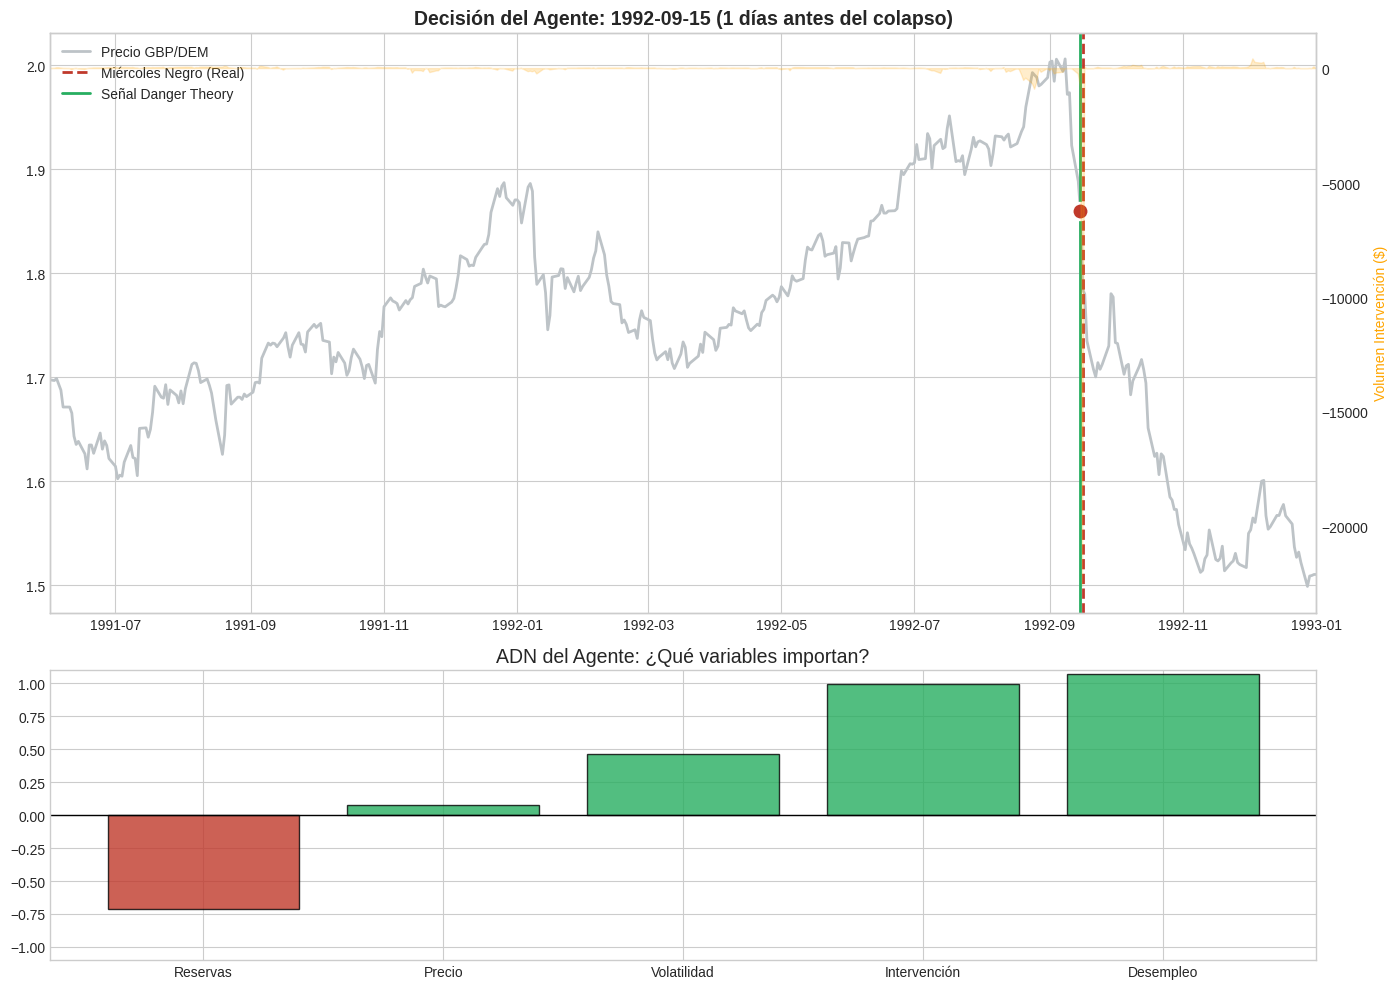

In [13]:
def main():
    random.seed(42) # Semilla para reproducibilidad
    
    # Crear población inicial
    pop = toolbox.population(n=150)
    
    # Hall of Fame (Guarda al mejor de todos los tiempos)
    hof = tools.HallOfFame(1)
    
    # Estadísticas para el log
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("max", np.max)
    
    print("🧬 Iniciando Evolución (50 Generaciones)...")
    
    # Algoritmo Evolutivo Simple
    pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=50, 
                                   stats=stats, halloffame=hof, verbose=True)
    return pop, log, hof

# ¡CORRER LA SIMULACIÓN!
pop, log, hof = main()
best_agent = hof[0]

# Nombres de los genes para la gráfica
genes_names = ['Reservas', 'Precio', 'Volatilidad', 'Intervención', 'Desempleo']

print(f"\n🏆 MEJOR AGENTE ENCONTRADO (Fitness: {best_agent.fitness.values[0]:.2f})")
print("-" * 40)
for name, val in zip(genes_names, best_agent):
    print(f"{name:.<20}: {val:+.4f}")

# --- RECONSTRUCCIÓN DE LA SEÑAL ---
signal = (best_agent[0]*df_env['Gen_Reservas']) + \
         (best_agent[1]*df_env['Gen_Precio']) + \
         (best_agent[2]*df_env['Gen_Volatilidad']) + \
         (best_agent[3]*df_env['Gen_Intervencion']) + \
         (best_agent[4]*df_env['Gen_Desempleo'])

# Encontrar el punto de salida
triggers = signal[signal > 0.5]
if not triggers.empty:
    exit_idx = triggers.index[0]
    date_out = df_env.loc[exit_idx, 'Date']
    price_out = df_env.loc[exit_idx, 'GBP']
    days_diff = (TARGET_DATE - date_out).days
else:
    date_out = None

# --- PLOTTEO ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# GRÁFICA 1: PRECIO Y DECISIÓN
ax1.plot(df_env['Date'], df_env['GBP'], label='Precio GBP/DEM', color='#bdc3c7', linewidth=2)
ax1.axvline(TARGET_DATE, color='#c0392b', linestyle='--', linewidth=2, label='Miércoles Negro (Real)')

# Pintar intervención de fondo (La señal oculta)
ax1_twin = ax1.twinx()
ax1_twin.fill_between(df_env['Date'], 0, df_env['Intervention'], color='orange', alpha=0.2, label='Intervención Banco Central')
ax1_twin.set_ylabel('Volumen Intervención ($)', color='orange')
ax1_twin.grid(False)

if date_out:
    ax1.axvline(date_out, color='#27ae60', linewidth=2, label='Señal Danger Theory')
    ax1.plot(date_out, price_out, 'o', color='#c0392b', markersize=12, markeredgecolor='white', markeredgewidth=2)
    ax1.set_title(f"Decisión del Agente: {date_out.date()} ({days_diff} días antes del colapso)", fontsize=14, weight='bold')
else:
    ax1.set_title("El agente no encontró salida", fontsize=14)

ax1.legend(loc='upper left')
ax1.set_xlim(pd.Timestamp('1991-06-01'), pd.Timestamp('1993-01-01'))

# GRÁFICA 2: IMPORTANCIA DE GENES (PESOS)
colors = ['#c0392b' if x < 0 else '#27ae60' for x in best_agent]
ax2.bar(genes_names, best_agent, color=colors, edgecolor='black', alpha=0.8)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title("ADN del Agente: ¿Qué variables importan?", fontsize=14)
ax2.set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

A continuación, visualizamos el comportamiento del "Super Agente" resultante.
* **Gráfico Superior:** Muestra el precio (Gris) y el momento exacto de salida (Punto Rojo). La línea vertical verde marca la decisión.
* **Gráfico Inferior:** Muestra la importancia de cada gen. 
    * Barras altas = Variables clave para la predicción.
    * Barras bajas = Ruido ignorado.